In [1]:
import os, glob, re, html, copy, random, time 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import torch
from torch.utils.data import DataLoader, Dataset
from torch.cuda.amp import autocast, GradScaler
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_cosine_schedule_with_warmup
from torch.optim import AdamW

# --- Import LoRA from PEFT ---
from peft import LoraConfig, get_peft_model, TaskType

from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# 0. Configuration and Random Seed Setup
# ==========================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)
    print(f"Random seed set to {seed}")

set_seed(42)

EVENT_WISE_DIR = '/kaggle/input/datasets/jieyang02/aa-nlp/aa - nlp/HumAID_data_event_wise'
EVENT_TYPE_DIR = '/kaggle/input/datasets/jieyang02/aa-nlp/aa - nlp/HumAID_data_event_type/event_type'

MODEL_NAME = 'answerdotai/ModernBERT-base'
BATCH_SIZE = 16 
ACCUMULATION_STEPS = 2   # Gradient accumulation, equivalent to real Batch Size = 16 * 2 = 32
MAX_LEN = 128
EPOCHS = 5               # LoRA converges slightly slower, so 5 epochs are sufficient with EarlyStopping
PATIENCE = 2
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Random seed set to 42


In [2]:
# ==========================================
# 1. Data Cleaning and DataLoaders
# ==========================================
def clean_tweet(text):
    if pd.isna(text): return ""
    text = html.unescape(str(text)).lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'\@\w+', '', text)
    
    # Disaster keyword de-biasing: Forces the model to learn contextual semantics 
    # rather than memorizing domain-specific disaster nouns
    disaster_keywords = ['earthquake', 'quake', 'fire', 'wildfire', 'flood', 'flooding', 'hurricane', 'storm', 'cyclone', 'typhoon']
    for kw in disaster_keywords:
        text = text.replace(kw, ' disaster ')
        
    text = text.replace('#', '')
    text = re.sub(r'(.)\1+', r'\1\1', text) 
    return " ".join(text.split())

class TweetDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len
        
    def __len__(self): 
        return len(self.texts)
    
    def __getitem__(self, i):
        enc = self.tokenizer(
            str(self.texts[i]),
            add_special_tokens=True, 
            max_length=self.max_len, 
            padding='max_length',
            truncation=True, 
            return_tensors='pt'
        )
        return {
            'input_ids': enc['input_ids'].flatten(),
            'attention_mask': enc['attention_mask'].flatten(), 
            'labels': torch.tensor(self.labels[i], dtype=torch.long)
        }

class EarlyStoppingF1:
    def __init__(self, patience=2):
        self.patience = patience
        self.counter = 0
        self.best_f1 = -1.0
        self.early_stop = False
        self.best_model_state = None

    def __call__(self, current_f1, model):
        if current_f1 > self.best_f1:
            self.best_f1 = current_f1
            # Save state dict to CPU memory to prevent GPU VRAM leakage across loops
            self.best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            self.counter = 0
            print(f"     --> [Best F1: {self.best_f1:.4f}] Weights Saved.")
        else:
            self.counter += 1
            if self.counter >= self.patience: 
                self.early_stop = True

In [3]:
# ==========================================
# 2. Build Data Dictionary and Labels
# ==========================================
print("\nBuilding Dictionary...")
tweet_text_dict = {}
for file_path in glob.glob(os.path.join(EVENT_WISE_DIR, '**/*.tsv'), recursive=True):
    if os.path.basename(file_path).startswith('._'): continue
    try:
        df_temp = pd.read_csv(file_path, sep='\t', dtype={'tweet_id': str})
        for _, row in df_temp.iterrows():
            if pd.notna(row['tweet_id']):
                tweet_text_dict[str(row['tweet_id'])] = clean_tweet(row['tweet_text'])
    except: pass

ALL_TYPES = ['earthquake', 'fire', 'flood', 'hurricane']
data_dict = {t: {'train': None, 'dev': None, 'test': None} for t in ALL_TYPES}

def load_split(d, s):
    path = os.path.join(EVENT_TYPE_DIR, f'{d}_{s}.tsv')
    if not os.path.exists(path): return pd.DataFrame()
    df = pd.read_csv(path, sep='\t', dtype={'tweet_id': str})
    df['tweet_text'] = df['tweet_id'].map(tweet_text_dict)
    return df.dropna(subset=['tweet_text', 'class_label'])

all_labels = []
for d in ALL_TYPES:
    for s in ['train', 'dev', 'test']:
        df = load_split(d, s)
        data_dict[d][s] = df
        if not df.empty: 
            all_labels.extend(df['class_label'].tolist())

# Global Label Encoder (11-Class Configuration)
label_encoder = LabelEncoder().fit(all_labels)
num_labels = len(label_encoder.classes_)
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


Building Dictionary...


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

In [4]:
# ==========================================
# 3. Leave-One-Type-Out (LOTO) Cross-Validation
# ==========================================
results = []
print("\n" + "="*80)
print("STARTING LEAVE-ONE-TYPE-OUT (LOTO) EXPERIMENT WITH ModernBERT + LoRA")
print("="*80)

total_experiment_start_time = time.time() 

for target_type in ALL_TYPES:
    source_types = [t for t in ALL_TYPES if t != target_type]
    print(f"\n[{target_type.upper()}] as Target | Source: {source_types}")
    
    # Combine train and dev data from source domains
    train_dfs_list = [data_dict[s]['train'] for s in source_types if not data_dict[s]['train'].empty]
    val_dfs_list = [data_dict[s]['dev'] for s in source_types if not data_dict[s]['dev'].empty]
    
    train_df = pd.concat(train_dfs_list, ignore_index=True)
    val_df = pd.concat(val_dfs_list, ignore_index=True)
    test_df = data_dict[target_type]['test']
    
    print(f" Train size: {len(train_df)} | Val size: {len(val_df)} | Test size: {len(test_df)}")

    y_train_idx = label_encoder.transform(train_df['class_label'])
    y_val_idx = label_encoder.transform(val_df['class_label'])
    y_test_idx = label_encoder.transform(test_df['class_label'])

    # --- Handle Extreme Class Imbalance via Clipped Weights ---
    class_counts = np.bincount(y_train_idx, minlength=num_labels)
    class_counts = np.maximum(class_counts, 1) # Prevent division by zero
    total_samples = len(y_train_idx)
    
    raw_weights = total_samples / (num_labels * class_counts)
    # Clip maximum weight to 5.0 to prevent exploding gradients on rare classes (e.g., missing_people)
    clipped_weights = np.clip(raw_weights, 1.0, 5.0)  
    weights_tensor = torch.tensor(clipped_weights, dtype=torch.float).to(DEVICE)
    
    loss_fn = torch.nn.CrossEntropyLoss(
        weight=weights_tensor, 
        label_smoothing=0.05 
    )

    train_loader = DataLoader(
        TweetDataset(train_df['tweet_text'].values, y_train_idx, tokenizer, MAX_LEN), 
        batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True
    )
    val_loader = DataLoader(
        TweetDataset(val_df['tweet_text'].values, y_val_idx, tokenizer, MAX_LEN), 
        batch_size=BATCH_SIZE, num_workers=4, pin_memory=True
    )
    test_loader = DataLoader(
        TweetDataset(test_df['tweet_text'].values, y_test_idx, tokenizer, MAX_LEN), 
        batch_size=BATCH_SIZE, num_workers=4, pin_memory=True
    )

    # -----------------------------------------------------
    # Deploy LoRA Configuration (Rank 16, increased dropout)
    # -----------------------------------------------------
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=num_labels
    ).to(DEVICE)
    
    lora_config = LoraConfig(
        task_type=TaskType.SEQ_CLS,       
        r=16,                             
        lora_alpha=32,                    
        lora_dropout=0.2,            
        target_modules="all-linear"       
    )
    
    
    model = get_peft_model(model, lora_config)
    print(">>> LoRA Parameters:")
    model.print_trainable_parameters()
    # -----------------------------------------------------
    
    # LoRA requires a relatively higher learning rate
    optimizer = AdamW(model.parameters(), lr=3e-4, weight_decay=0.01)
    
    total_steps = ((len(train_loader) + ACCUMULATION_STEPS - 1) // ACCUMULATION_STEPS) * EPOCHS
    scheduler = get_cosine_schedule_with_warmup(
        optimizer, 
        num_warmup_steps=int(0.1 * total_steps), 
        num_training_steps=total_steps
    )
    
    es = EarlyStoppingF1(patience=PATIENCE)
    scaler = GradScaler()

    fold_history = {'t_loss': [], 'v_loss': [], 't_f1': [], 'v_f1': []}

    # --- Training & Validation Loop ---
    for epoch in range(EPOCHS):
        epoch_start_time = time.time() 
        model.train()
        t_loss, t_true, t_preds = 0, [], []
        loop = tqdm(train_loader, desc=f" Epoch {epoch+1}/{EPOCHS} Train", leave=False)
        
        optimizer.zero_grad() 
        
        for step, batch in enumerate(loop):
            labels = batch['labels'].to(DEVICE)
            
            with autocast():
                logits = model(batch['input_ids'].to(DEVICE), attention_mask=batch['attention_mask'].to(DEVICE)).logits
                loss = loss_fn(logits, labels)
                loss = loss / ACCUMULATION_STEPS
            
            scaler.scale(loss).backward()
            
            if (step + 1) % ACCUMULATION_STEPS == 0 or (step + 1) == len(train_loader):
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                scaler.step(optimizer)
                scaler.update()
                scheduler.step()
                optimizer.zero_grad() 
            
            t_loss += loss.item() * ACCUMULATION_STEPS
            t_preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
            t_true.extend(labels.cpu().numpy())
            
        avg_t_loss = t_loss / len(train_loader)
        
        # Dynamically extract actually present labels to avoid 0.0 penalty for missing classes
        present_labels_t = np.unique(t_true)
        t_f1 = f1_score(t_true, t_preds, labels=present_labels_t, average='macro', zero_division=0)

        # Validation Phase
        model.eval()
        v_loss, v_true, v_preds = 0, [], []
        with torch.no_grad():
            for batch in val_loader:
                labels = batch['labels'].to(DEVICE)
                with autocast():
                    logits = model(batch['input_ids'].to(DEVICE), attention_mask=batch['attention_mask'].to(DEVICE)).logits
                    loss = loss_fn(logits, labels)
                
                v_loss += loss.item()
                v_preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
                v_true.extend(labels.cpu().numpy())
                
        avg_v_loss = v_loss / len(val_loader)
        
        present_labels_v = np.unique(v_true)
        v_f1 = f1_score(v_true, v_preds, labels=present_labels_v, average='macro', zero_division=0)
        
        epoch_time = time.time() - epoch_start_time
        print(f" Epoch {epoch+1:02d} | Time: {epoch_time:.0f}s | T-Loss: {avg_t_loss:.4f} | T-F1: {t_f1:.4f} || V-Loss: {avg_v_loss:.4f} | V-F1: {v_f1:.4f}")

        # Save history for curves
        fold_history['t_loss'].append(avg_t_loss)
        fold_history['v_loss'].append(avg_v_loss)
        fold_history['t_f1'].append(t_f1)
        fold_history['v_f1'].append(v_f1)
        
        es(v_f1, model)
        if es.early_stop: 
            print("     --> Early stopping triggered.")
            break

    # --- Target Final Evaluation ---
    print(f"\n Evaluating on Target: {target_type.upper()}...")
    
    best_state_dict = {k: v.to(DEVICE) for k, v in es.best_model_state.items()}
    model.load_state_dict(best_state_dict)
    model.eval()
    y_probs, y_preds = [], []
    
    with torch.no_grad():
        for batch in test_loader:
            with autocast():
                logits = model(batch['input_ids'].to(DEVICE), attention_mask=batch['attention_mask'].to(DEVICE)).logits
                y_probs.extend(torch.nn.functional.softmax(logits, dim=1).cpu().numpy())
                y_preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
                
    y_probs = np.array(y_probs)
    y_preds = np.array(y_preds)
    
    acc = accuracy_score(y_test_idx, y_preds)
    
    # Calculate scores solely on labels present in the target test set
    present_labels_test = np.unique(y_test_idx)
    
    f1_macro = f1_score(y_test_idx, y_preds, labels=present_labels_test, average='macro', zero_division=0)
    f1_weighted = f1_score(y_test_idx, y_preds, labels=present_labels_test, average='weighted', zero_division=0)
    
    print(f" >>> Target Accuracy: {acc:.4f} | Target Macro F1: {f1_macro:.4f} | Target Weighted F1: {f1_weighted:.4f}\n")

    save_dir = f"saved_lora_models/lora_no_{target_type}"
    os.makedirs(save_dir, exist_ok=True)
    
    model.save_pretrained(save_dir)
    print(f" [Model Saved] LoRA weights (Unseen: {target_type.upper()}) saved to {save_dir}/")
    
    results.append({
        'Test_Disaster': target_type.capitalize(),
        'Accuracy': acc, 
        'F1_Macro': f1_macro,
        'F1_Weighted': f1_weighted,
        'y_true': y_test_idx,
        'y_preds': y_preds,
        'test_texts': test_df['tweet_text'].values,
        'history': fold_history
    })

total_time = time.time() - total_experiment_start_time
print(f"\nTotal Experiment Time: {total_time/60:.2f} minutes")


STARTING LEAVE-ONE-TYPE-OUT (LOTO) EXPERIMENT WITH ModernBERT + LoRA

[EARTHQUAKE] as Target | Source: ['fire', 'flood', 'hurricane']
 Train size: 47281 | Val size: 6884 | Test size: 1773


model.safetensors:   0%|          | 0.00/599M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

ModernBertForSequenceClassification LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.weight | MISSING    | 
classifier.bias   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


>>> LoRA Parameters:
trainable params: 3,411,466 || all params: 153,024,020 || trainable%: 2.2294


...

 Epoch 01 | Time: 254s | T-Loss: 1.2796 | T-F1: 0.6090 || V-Loss: 0.9618 | V-F1: 0.7438
     --> [Best F1: 0.7438] Weights Saved.


 Epoch 02 | Time: 255s | T-Loss: 0.8978 | T-F1: 0.7593 || V-Loss: 0.9354 | V-F1: 0.7418


 Epoch 03 | Time: 254s | T-Loss: 0.7850 | T-F1: 0.8185 || V-Loss: 0.9369 | V-F1: 0.7595
     --> [Best F1: 0.7595] Weights Saved.


 Epoch 04 | Time: 255s | T-Loss: 0.6716 | T-F1: 0.8812 || V-Loss: 0.9816 | V-F1: 0.7519


 Epoch 05 | Time: 254s | T-Loss: 0.6022 | T-F1: 0.9236 || V-Loss: 1.0125 | V-F1: 0.7522
     --> Early stopping triggered.

 Evaluating on Target: HURRICANE...
 >>> Target Accuracy: 0.7356 | Target Macro F1: 0.6973 | Target Weighted F1: 0.7226

 [Model Saved] LoRA weights (Unseen: HURRICANE) saved to saved_lora_models/lora_no_hurricane/

Total Experiment Time: 157.46 minutes



LEAVE-ONE-TYPE-OUT FINAL EXPERIMENTAL REPORT
Test_Disaster  Accuracy  F1_Macro  F1_Weighted
   Earthquake  0.830795  0.753825     0.834382
         Fire  0.782057  0.730897     0.783216
        Flood  0.761518  0.686174     0.760034
    Hurricane  0.735557  0.697318     0.722594
------------------------------------------------------------
Average Accuracy:    0.7775
Average F1 Macro:    0.7171
Average F1 Weighted: 0.7751


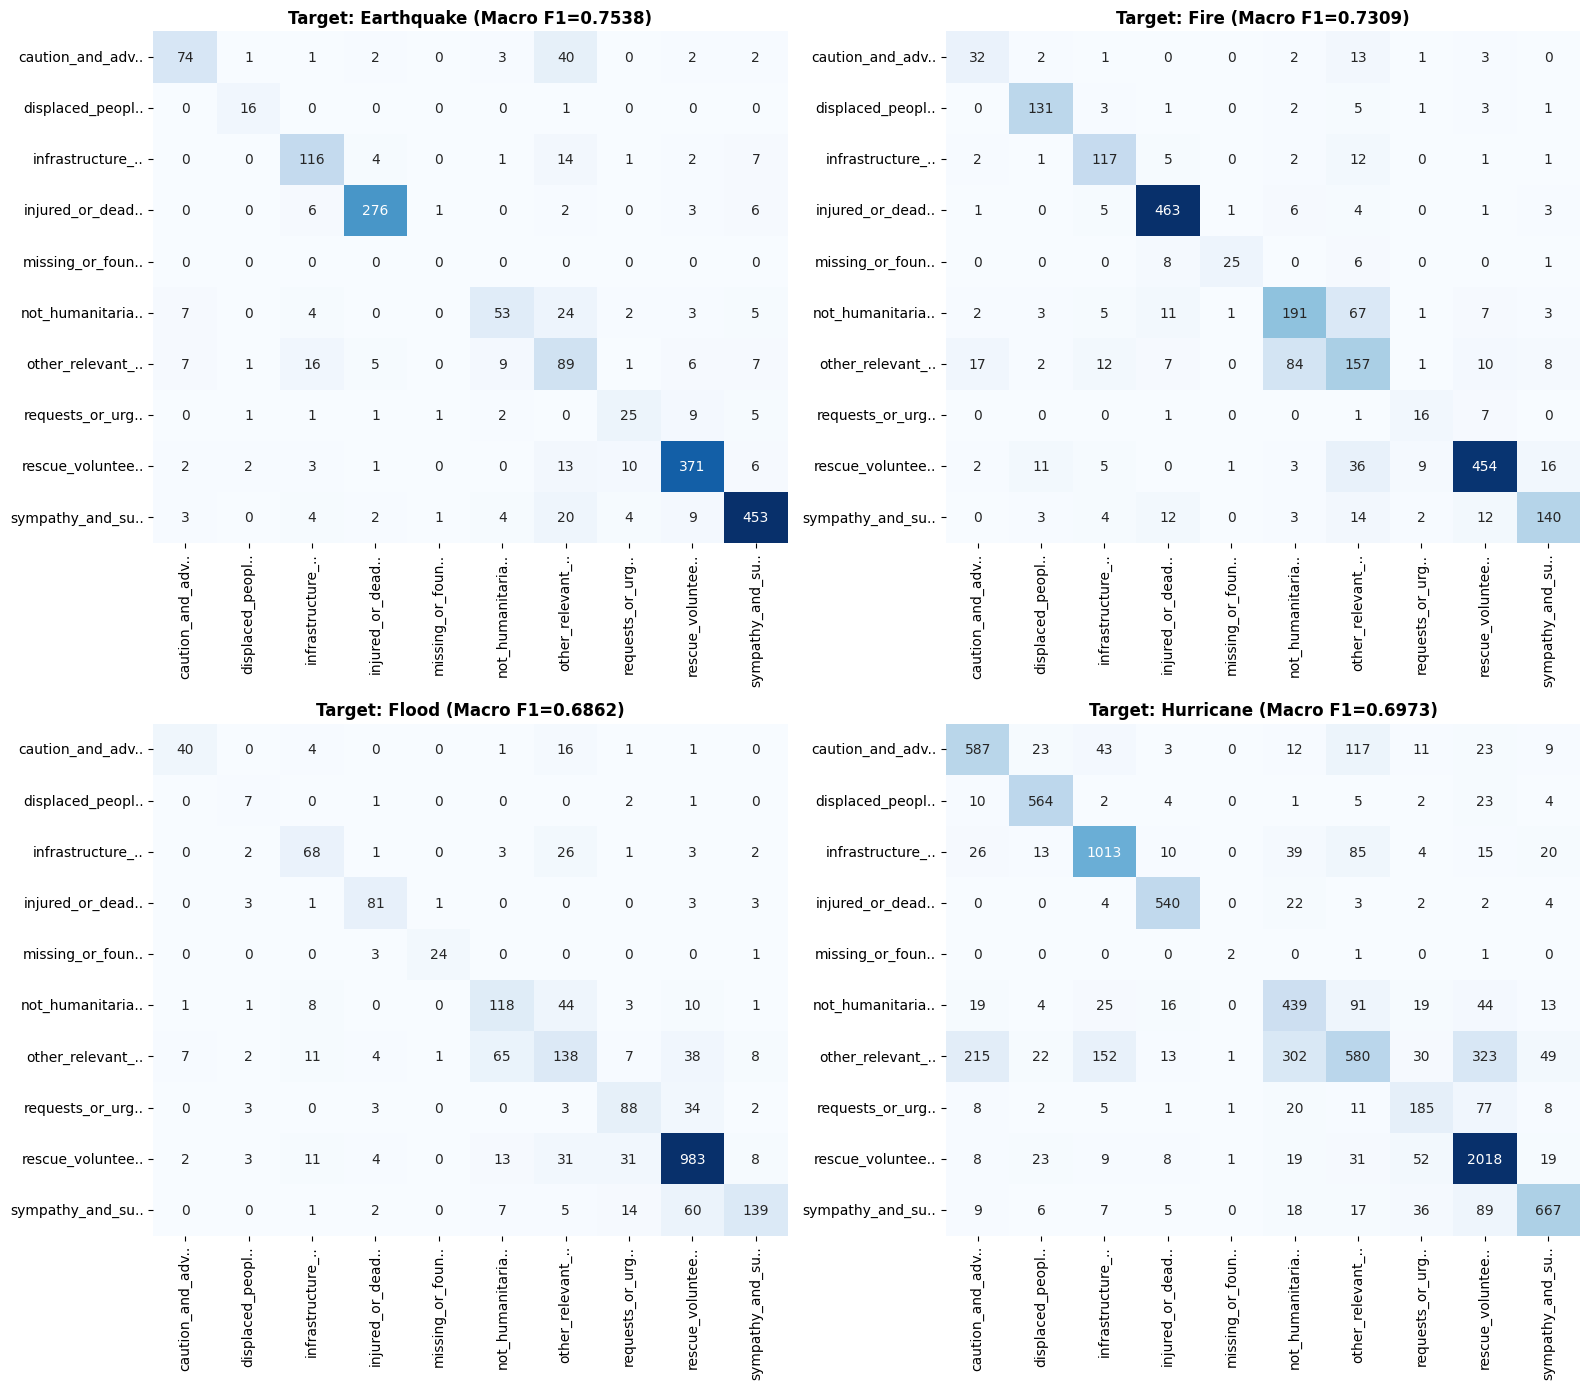

In [5]:
# ==========================================
# Section 4: Summary Report & Confusion Matrices
# ==========================================
res_df = pd.DataFrame(results)
print("\n" + "="*60)
print("LEAVE-ONE-TYPE-OUT FINAL EXPERIMENTAL REPORT")
print("="*60)
print(res_df[['Test_Disaster', 'Accuracy', 'F1_Macro', 'F1_Weighted']].to_string(index=False))
print("-" * 60)
print(f"Average Accuracy:    {res_df['Accuracy'].mean():.4f}")
print(f"Average F1 Macro:    {res_df['F1_Macro'].mean():.4f}")
print(f"Average F1 Weighted: {res_df['F1_Weighted'].mean():.4f}")
print("="*60)

# 1. Confusion Matrix Plot
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
short_names = [n[:15] + '..' if len(n) > 15 else n for n in label_encoder.classes_]

for i, r in enumerate(results):
    cm = confusion_matrix(r['y_true'], r['y_preds'], labels=range(num_labels))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes.flatten()[i], 
                xticklabels=short_names, yticklabels=short_names, cbar=False)
    axes.flatten()[i].set_title(f"Target: {r['Test_Disaster']} (Macro F1={r['F1_Macro']:.4f})", fontweight='bold')

plt.tight_layout()
plt.show()

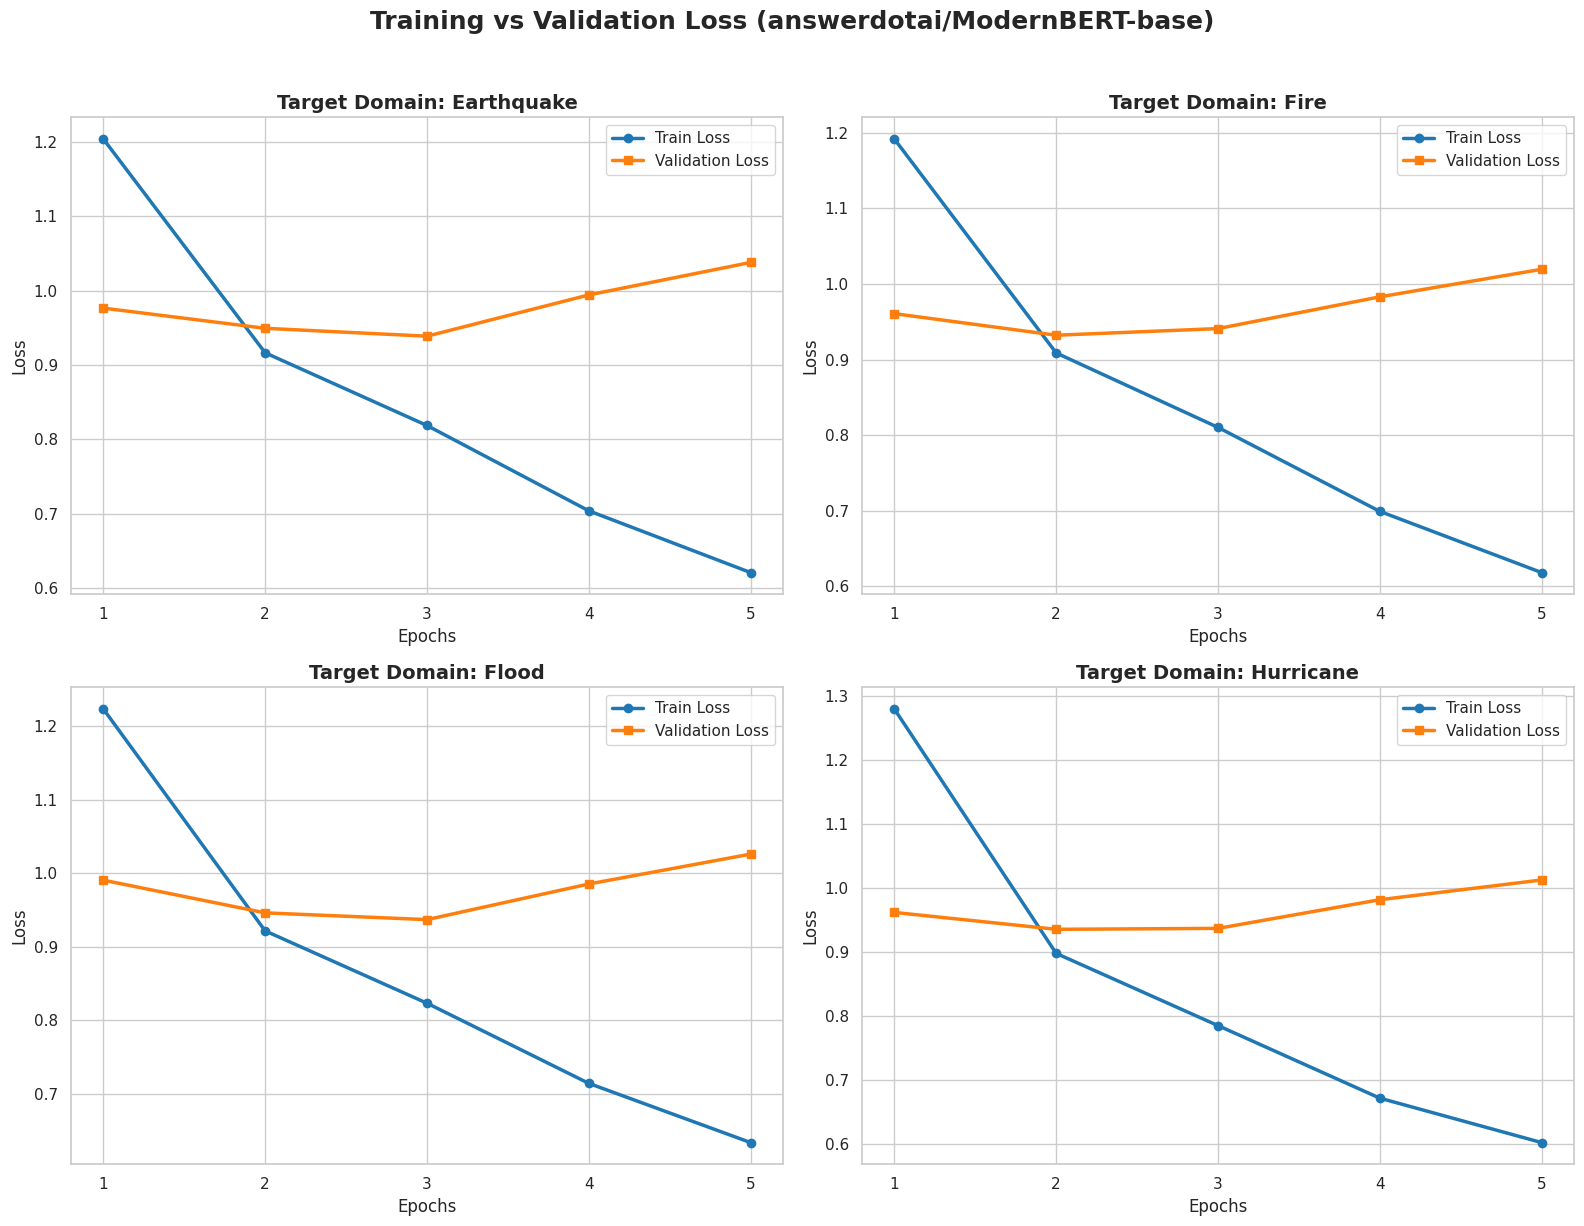

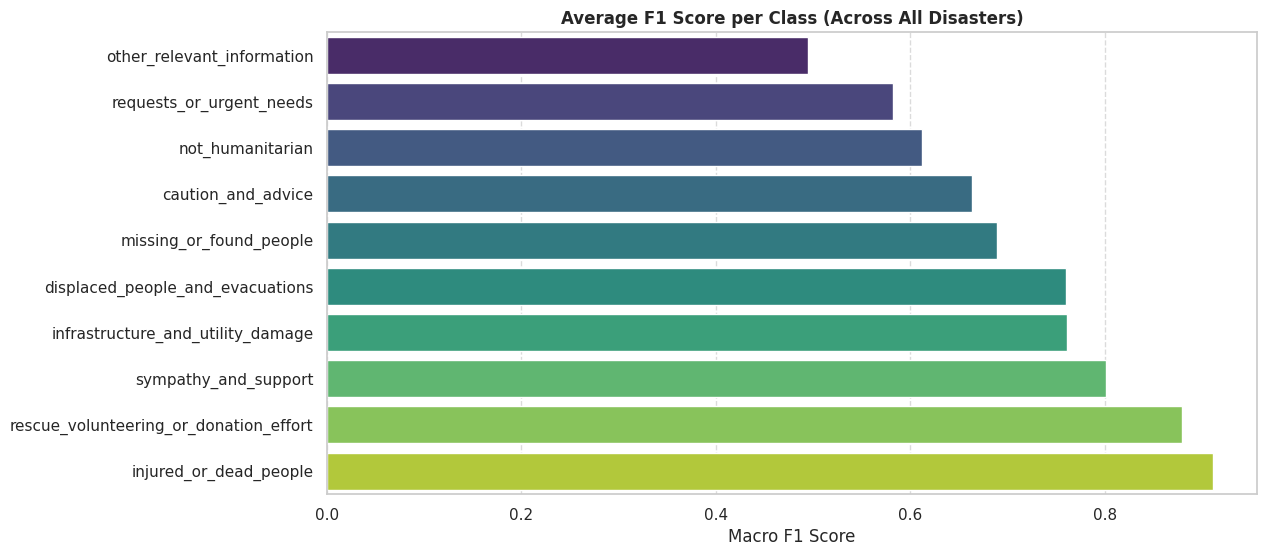


10 RANDOM CORRECT PREDICTIONS (Model Insights)


,Domain,Tweet Text,True Label,Predicted Label
0,Fire,"pray for the people of greece | greece wild disaster s: dozens killed near athens, officials say πυρκαγια",sympathy_and_support,sympathy_and_support
1,Flood,"honoured the fishermen for their selfless service, courage, determination & the risky efforts at kozhikode today. they risked their own lives to save countless lives in the kerala disaster s .",rescue_volunteering_or_donation_effort,rescue_volunteering_or_donation_effort
2,Hurricane,cuba really got it last night from irma 😭 praying for my family there and everyone in the caribbean that was affected. 🙏🏼,sympathy_and_support,sympathy_and_support
3,Hurricane,"you didn’t think he was actually telling the truth, did you? why would he set such a precedent all of a sudden?! but, how much fema cash is he going to pocket if any of his personal florida properties are damaged by dorian?",not_humanitarian,not_humanitarian
4,Hurricane,"we will donate $1 from every ticket sold for the astros series, sept. 8-10, to disaster harvey relief efforts. 🎟️",rescue_volunteering_or_donation_effort,rescue_volunteering_or_donation_effort
5,Hurricane,photos from the south asian disaster that left 1200 people dead but no one talked about -,injured_or_dead_people,injured_or_dead_people
6,Hurricane,": stay safe in your travels. even though disaster florence has passed, extreme dangers still exist. inland disaster ing is the 1 cause of tropical disaster fatalities. do not drive through standing water. a few inches of water can sweep a car away",caution_and_advice,caution_and_advice
7,Hurricane,"houston dries, damage assessments begin after harveys historic disaster ing. wbts morning news w on now",infrastructure_and_utility_damage,infrastructure_and_utility_damage
8,Fire,greece wild disaster s called europe’s ‘deadliest’ in a century as rising death toll hits 91 — rt world news,injured_or_dead_people,injured_or_dead_people
9,Hurricane,"haiti is still messed up from the disaster , i was there. now this disaster fucking it up even more. im glad my immediate family is ok",other_relevant_information,other_relevant_information



10 RANDOM INCORRECT PREDICTIONS (Error Analysis)


,Domain,Tweet Text,True Label,Predicted Label
0,Flood,humanity is above all. k j jaydeep a groom whose wedding has been postponed due to disaster s in kerala proved it by turning the wedding venue into a relief camp for the stranded. your support is awaited keralarelieffund,rescue_volunteering_or_donation_effort,sympathy_and_support
1,Hurricane,"giving lyft, uber and yellow cabs rides to shelters this morning, if you live in little havana, overtown, liberty city disaster irma",other_relevant_information,rescue_volunteering_or_donation_effort
2,Hurricane,"all power out as disaster maria’s winds, disaster s crush puerto rico-worst case is island",infrastructure_and_utility_damage,other_relevant_information
3,Hurricane,trump is turning disaster harvey into a campaign rally.,other_relevant_information,not_humanitarian
4,Hurricane,disaster is an important part of our western forest ecosystems. due to misguided citizens and politicians we are still fighting too many disaster s.,not_humanitarian,other_relevant_information
5,Hurricane,rt : i heart dominica tee! 100% of profits go to dominicans affected by disaster maria! shop now @,other_relevant_information,rescue_volunteering_or_donation_effort
6,Hurricane,"unfortunately, great abaco island and marsh harbour are about to be impacted by dorian directly. now a category 5 with 175 mph winds and gusts near 200 mph. catastrophic damage inevitable.",caution_and_advice,infrastructure_and_utility_damage
7,Flood,kerala disaster s amount given by kerala cm from salaries : 0.1 cr amount given by delhi cm from salaries : 1 cr amount given by kerala towards disaster s in other states : 0 cr amount given by other states to kerala : 100 cr karma,rescue_volunteering_or_donation_effort,not_humanitarian
8,Fire,washington disaster fighters returning from california wild disaster s,rescue_volunteering_or_donation_effort,other_relevant_information
9,Flood,india govts stated policy not to accept foreign aid not specific to kerala disaster s still such funds can be channeled thru 100s of ngos/ biz houses in the state,rescue_volunteering_or_donation_effort,other_relevant_information


In [6]:
# ==========================================
# Section 5: Error Analysis & Insights Visualization
# ==========================================

# 1. Plotting Learning Curves (Loss)
sns.set_theme(style="whitegrid")
fig_loss, axes_loss = plt.subplots(2, 2, figsize=(16, 12))
fig_loss.suptitle(f'Training vs Validation Loss ({MODEL_NAME})', fontsize=18, fontweight='bold', y=1.02)

for i, res in enumerate(results):
    ax = axes_loss.flatten()[i]
    history = res['history']
    epochs = range(1, len(history['t_loss']) + 1)
    ax.plot(epochs, history['t_loss'], label='Train Loss', marker='o', linewidth=2.5, color='#1f77b4')
    ax.plot(epochs, history['v_loss'], label='Validation Loss', marker='s', linewidth=2.5, color='#ff7f0e')
    ax.set_title(f"Target Domain: {res['Test_Disaster']}", fontsize=14, fontweight='bold')
    ax.set_xlabel('Epochs', fontsize=12)
    ax.set_ylabel('Loss', fontsize=12)
    ax.set_xticks(epochs)
    ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

# 2. Plot Average Class-wise F1 Scores across all Domains
class_f1_scores = {c: [] for c in label_encoder.classes_}

for res in results:
    # Compute F1 for all classes. Missing classes in a test set will yield 0.0 (ignored in valid mean later)
    f1_per_class = f1_score(res['y_true'], res['y_preds'], average=None, labels=range(num_labels), zero_division=0)
    present_labels = np.unique(res['y_true'])
    
    for i, c in enumerate(label_encoder.classes_):
        # Only append F1 score if the class was actually present in the test set
        if i in present_labels:
            class_f1_scores[c].append(f1_per_class[i])

# Calculate valid average
avg_class_f1 = {c: np.mean(scores) if len(scores) > 0 else 0.0 for c, scores in class_f1_scores.items()}

plt.figure(figsize=(12, 6))
class_df = pd.DataFrame(list(avg_class_f1.items()), columns=['Class', 'Average F1']).sort_values(by='Average F1', ascending=True)
sns.barplot(x='Average F1', y='Class', data=class_df, palette='viridis')
plt.title("Average F1 Score per Class (Across All Disasters)", fontweight='bold')
plt.xlabel("Macro F1 Score")
plt.ylabel("")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()


# 3. Qualitative Error Analysis: Random Correct & Incorrect Predictions
all_texts, all_trues, all_preds, all_domains = [], [], [], []

for res in results:
    all_texts.extend(res['test_texts'])
    all_trues.extend(res['y_true'])
    all_preds.extend(res['y_preds'])
    all_domains.extend([res['Test_Disaster']] * len(res['test_texts']))

analysis_df = pd.DataFrame({
    'Domain': all_domains,
    'Tweet Text': all_texts,
    'True Label': label_encoder.inverse_transform(all_trues),
    'Predicted Label': label_encoder.inverse_transform(all_preds)
})

correct_df = analysis_df[analysis_df['True Label'] == analysis_df['Predicted Label']]
incorrect_df = analysis_df[analysis_df['True Label'] != analysis_df['Predicted Label']]

print("\n" + "="*80)
print("10 RANDOM CORRECT PREDICTIONS (Model Insights)")
print("="*80)
# Set pandas option to show full text
pd.set_option('display.max_colwidth', None)
display(correct_df.sample(min(10, len(correct_df)), random_state=42).reset_index(drop=True))

print("\n" + "="*80)
print("10 RANDOM INCORRECT PREDICTIONS (Error Analysis)")
print("="*80)
display(incorrect_df.sample(min(10, len(incorrect_df)), random_state=42).reset_index(drop=True))
pd.reset_option('display.max_colwidth') # reset option